# Week 1 Challenge Project Template

You are not required to use this template, but we are providing it for your reference to help get you started and stay organized!  We recommend that you define functions for each step to make it easier to track what's going on in the code (especially if different team members are working on different pieces of the project).

Most of the functions provided are just examples!  Feel free to replace them with something better!  This is just a minimum working example.

## 1. Load the data

In [1]:
import pandas as pd
import numpy as np

%matplotlib inline

In [2]:
train_url = "https://raw.githubusercontent.com/MedlyticsUniversal/Data/main/Week1/allhypo.train.csv"
test_url = "https://raw.githubusercontent.com/MedlyticsUniversal/Data/main/Week1/allhypo.test.csv"
test_labels_url = "https://raw.githubusercontent.com/OmarSourman/Medlytics_2026/main/Week%201/ChallengeProject/allhypo.test.labels.csv"

data_train = pd.read_csv(train_url)
data_test = pd.read_csv(test_url)   # this will not have a 'class' column!
test_labels_df = pd.read_csv(test_labels_url, names = ['Class'], skiprows=1)

# convert '?' values to NaN for proper handling in preprocessing
data_train.replace('?', np.nan, inplace=True)
data_test.replace('?', np.nan, inplace=True)

#attach test_labels_df to test_df
data_test['Class'] = test_labels_df['Class']

# identify columns by what time of data they hold
numeric_columns=list(["Age","TSH","T3","TT4","T4U","FTI"])

# categorical columns are everything else (minus 'class')
categorical_columns = list(set(data_train.columns)-set(numeric_columns)-set(['class']))

/tmp/ipykernel_952/2052162480.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_train.replace('?', np.nan, inplace=True)
/tmp/ipykernel_952/2052162480.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_test.replace('?', np.nan, inplace=True)


## 2. Format your class labels
Turn multi-classes into binary classes

In [3]:
def format_class_labels(df):

    import re

    # regex the weird class labels out
    regex_pattern = ( "\.\|\d+")

    for index, row in df.iterrows():

        # substitute instances of our regex_pattern for an empty string
        new_class = re.sub(regex_pattern, '', row['Class'])
        df.loc[index,'class']=new_class

    # set all negative class labels to 0, all others to 1

    df['class'] = df['class'].replace('negative', 0)
    df['class'] = df['class'].replace('compensated hypothyroid', 1)
    df['class'] = df['class'].replace('primary hypothyroid', 1)
    df['class'] = df['class'].replace('secondary hypothyroid', 1)

    return df

data_train = format_class_labels(data_train)

<>:6: SyntaxWarning: invalid escape sequence '\.'
<>:6: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_952/4018110264.py:6: SyntaxWarning: invalid escape sequence '\.'
  regex_pattern = ( "\.\|\d+")
/tmp/ipykernel_952/4018110264.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['class'] = df['class'].replace('secondary hypothyroid', 1)


## 3. Split training into training and validation
Choose what split you like (alternatively, you can do k-fold cross validation)

In [4]:
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(data_train, test_size=0.20, random_state=0, stratify=data_train['class'])

## 4. Clean/format the data
Note: removing rows is probably a bad idea because you won't be able to do this to the test data!  Try to come up with some clever ways to handle the "?" values.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# drop both 'class' and the original 'Class' to prevent leakage
X_train = data_train.drop(['class', 'Class'], axis=1, errors='ignore')
X_val = data_val.drop(['class', 'Class'], axis=1, errors='ignore')

#only contains class/diagnosis
y_train = data_train['class']
y_val = data_val['class']

# exclude uninformative columns
current_numeric_features = [col for col in numeric_columns if col in X_train.columns]

# exclude uninformative & entirely NaN columns. Check/Prevent numeric/categoric mixing
# exclude columns that are entirely NaN (useless)
current_categorical_features = [col for col in categorical_columns if col in X_train.columns and col not in current_numeric_features and not X_train[col].isnull().all()]

# NaNs in numeric columns are filled in with the median value in that category
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# NaNs in categorical columns are filled with the most frequent item in that category
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# preprocess using the transformers defined above
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, current_numeric_features),
        ('cat', categorical_transformer, current_categorical_features)
    ])

X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)

In [6]:
def get_uninformative_columns(df):

    drop_columns = []

    for col in df.columns:

        # if this column has only one value, we can't learn anything from it
        if(len(df[col].unique()) == 1):
            drop_columns.append(col)

    return drop_columns


# drop the uninformative features
drop_columns = get_uninformative_columns(data_train)

# Make sure you do the same thing to train & val
data_train=data_train.drop(drop_columns,axis=1)
data_val=data_val.drop(drop_columns,axis=1)

## 5. Define and Train the Model
You might want to consider having one process for training on one dataset and evaluating on another.  That way you can use the same code for your train/validation as you do for your train/test

In [7]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# instantiate random forest model
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=0)

rf_model.fit(X_train_processed, y_train.astype(int))

y_val_proba = rf_model.predict_proba(X_val_processed)

print("Random Forest Model trained successfully.")

Random Forest Model trained successfully.


## 6. Evaluate your model

### Confusion Matrix Metric

In [8]:
from sklearn.metrics import confusion_matrix
import numpy as np

# evaluate on validation set - Ensure labels are cast to int
y_val = data_val['class'].astype(int)

# This is exactly the first metric you'll be evaluated on!
# Note: this will only work on the binary case -- let us know if you get to the multi-class case

def cm_metric(y_true, y_prob):
    # predict the class with the greatest probability
    y_val_predict = [np.argmax(y) for y in y_prob]

    # calculate the confusion matrix
    cm = confusion_matrix(y_true, y_val_predict)

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    print(cm_norm)
    return sum(sum(np.multiply(cm_norm, np.array([[1, -2], [-2, 1]]))))

print('Confusion Matrix Metric: ', cm_metric(y_val, y_val_proba))

[[1.         0.        ]
 [0.02272727 0.97727273]]
Confusion Matrix Metric:  1.9318181818181819


### AUC

In [9]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

fpr, tpr, threshold = roc_curve(y_val, y_val_proba[:,1])
roc_auc = auc(fpr, tpr)
print('AUC: ',roc_auc)



AUC:  1.0


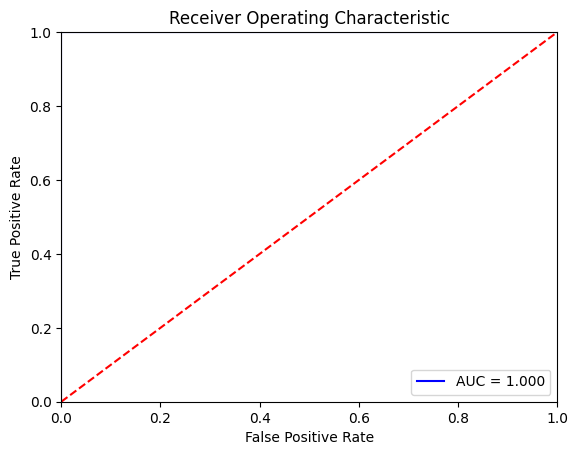

In [10]:
import matplotlib.pyplot as plt
plt.title('Receiver Operating Characteristic')
plt.plot(fpr, tpr, 'b', label = 'AUC = %0.3f' % roc_auc)
plt.legend(loc = 'lower right')
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.ylabel('True Positive Rate')
plt.xlabel('False Positive Rate')
plt.show()

## 7. Apply to test data - Undone
Once you're happy with your model, you should go through the same procedure again except:
* train with ALL the training data (re-combine with training and validation)
* test on test data (you won't be able to evaluate -- that's for us to do!)

In [11]:
# 1. Load data
train_url = "https://raw.githubusercontent.com/MedlyticsUniversal/Data/main/Week1/allhypo.train.csv"
test_url = "https://raw.githubusercontent.com/MedlyticsUniversal/Data/main/Week1/allhypo.test.csv"
data_train_full = pd.read_csv(train_url)
data_test_raw = pd.read_csv(test_url)

# 2. Clean '?' and format labels
data_train_full.replace('?', np.nan, inplace=True)
data_test_raw.replace('?', np.nan, inplace=True)
data_train_full = format_class_labels(data_train_full)

# 3. Identify features (excluding labels and non-clinical metadata)
target_col = 'class'
ignore_cols = ['Class', 'Referral Source', 'TBG', 'TBG Measured']
clinical_features = [col for col in data_train_full.columns if col not in [target_col] + ignore_cols]

X_train_full = data_train_full[clinical_features]
y_train_full = data_train_full[target_col].astype(int)
X_test_final = data_test_raw[clinical_features]

# 4. Re-configure preprocessor to only use valid clinical features
num_f = [f for f in numeric_columns if f in clinical_features]
cat_f = [f for f in clinical_features if f not in num_f]

final_preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_f),
    ('cat', categorical_transformer, cat_f)
])

# 5. Fit on full training data and transform both
X_train_full_proc = final_preprocessor.fit_transform(X_train_full)
X_test_proc = final_preprocessor.transform(X_test_final)

# 6. Train final Random Forest
final_rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=0)
final_rf_model.fit(X_train_full_proc, y_train_full)

# 7. Generate final test probabilities
y_test_proba = final_rf_model.predict_proba(X_test_proc)

print("Final model trained and test predictions generated successfully.")
y_test_df = pd.DataFrame(y_test_proba, columns=[0, 1])
print(y_test_df.head())

/tmp/ipykernel_952/433612012.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_train_full.replace('?', np.nan, inplace=True)
/tmp/ipykernel_952/433612012.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_test_raw.replace('?', np.nan, inplace=True)
/tmp/ipykernel_952/4018110264.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option(

Final model trained and test predictions generated successfully.
      0     1
0  1.00  0.00
1  1.00  0.00
2  0.93  0.07
3  1.00  0.00
4  1.00  0.00


## 8. Submit your attempt!

Once you've run on the test data, send a pickle file containing your predictions contained a pandas dataframe.  This pandas dataframe will contain two columns for your binary classifier (or 4 columns for the multiclass classifier) that looks like this (*pay attention to the column names!*):

|   | 0 | 1   |
|---|---|------|
| 0 | $p_{0,0}$ | $p_{0,1}$|
| 1 | $p_{1,0}$ | $p_{1,1}$|
| 2 | $p_{2,0}$ | $p_{2,1}$|
| ... | ... | ...|
| N | $p_{N,0}$ | $p_{N,1}$|

where $p_{i,j}$ corresponds to the probability of data point $i$ belonging to class $j$.

In [12]:
from google.colab import files
import pickle

# create a pickle file (this will save to the Google cloud)
prediction_pickle_path = 'teamname_week1_attempt1.pkl'
prediction_pickle = open(prediction_pickle_path, 'wb')
pickle.dump(y_test_proba, prediction_pickle)

# download the pickle file and save it somewhere to your computer, and email it to
files.download(prediction_pickle_path)
prediction_pickle.close()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Moving to the Next Level

For those that finish early, remember how I converted the class values into simply "negative" and "positive"? Now try tackling the multiclass classifier (predicting the different types of positive hypothyroid cases instead of simply negative or positive)!

The same rules apply!  (Note: for the multiclass problem, the AUC calculation will be the micro-average over your classes.)